# **TASK1**. Random Sampling (1 pts)

In [ ]:
import pandas as pdaFrame
df = pd.read_csv(file_path)

# Create a 90% random sample
sample_df = df.sample(frac=0.9

# Define the file path
file_path = '/content/RetailCustomerInsights.csv'

# Define the random seed
random_seed = 70864697

# Read the CSV file into a Dat, random_state=random_seed)

# Print the number of rows in the sample
print(f"Number of rows in the sample: {len(sample_df)}")

Number of rows in the sample: 900


# **TASK2**.  Drop Identifier (1 pt)
Remove the CustomerID column from your sample.

In [2]:
sample_df.drop('CustomerID', axis=1, inplace=True)
print(sample_df.head())

     Age  Income  SpendingScore  LoyaltyYears  FrequencyOfVisits  \
544   18   37700      26.690297             0                  1   
843   45   76809      42.018715             5                  3   
517   31   44352      39.580611             3                  5   
537   32   71901      36.107643             3                  4   
462   30   63416      41.071055             5                  6   

     AvgTransactionValue Region  ProductAffinityScore  
544            39.445514  North                 0.282  
843            96.796982   East                 0.638  
517            77.726016   West                 0.441  
537           100.825093   West                 0.436  
462            79.982356  North                 0.436  


# **TASK3**.  Prepare Data for PCA (2 pts).
* One-hot encode 'Region' and prevent multicollinearity.
* Standardize all numeric variables using Z-score scaling (mean = 0, std = 1).

In [4]:
from sklearn.preprocessing import StandardScaler

# One-hot encode 'Region' and prevent multicollinearity
df_encoded = pd.get_dummies(sample_df, columns=['Region'], drop_first=True)

# Identify numeric columns for standardization (all columns except the encoded ones)
numeric_cols = df_encoded.select_dtypes(include=['number']).columns

# Standardize numeric variables using Z-score scaling
scaler = StandardScaler()
df_processed = df_encoded.copy()
df_processed[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print("Shape of processed DataFrame:", df_processed.shape)
print("First 5 rows of processed DataFrame:")
print(df_processed.head())

Shape of processed DataFrame: (900, 10)
First 5 rows of processed DataFrame:
          Age    Income  SpendingScore  LoyaltyYears  FrequencyOfVisits  \
544 -1.814055 -1.866624      -1.312068     -1.701829          -2.110365   
843  0.410375  0.076443      -0.443930      0.192366          -1.159750   
517 -0.743033 -1.536130      -0.582015     -0.565312          -0.209135   
537 -0.660646 -0.167403      -0.778709     -0.565312          -0.684443   
462 -0.825419 -0.588967      -0.497602      0.192366           0.266172   

     AvgTransactionValue  ProductAffinityScore  Region_North  Region_South  \
544            -2.137009             -2.061133          True         False   
843            -0.103742              0.233080         False         False   
517            -0.779860             -1.036471         False         False   
537             0.039066             -1.068693         False         False   
462            -0.699866             -1.068693          True         False   

   

# **TASK4**.  Perform PCA (2 pts)

*   Apply PCA on the standardized data.

*   Display explained variance ratios.

✔️ Print explained variance per component.




In [5]:
from sklearn.decomposition import PCA

# Apply PCA on the standardized data
pca = PCA()
pca.fit(df_processed)

# Display explained variance ratios
print("Explained variance per component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")

Explained variance per component:
PC1: 0.6914
PC2: 0.0734
PC3: 0.0575
PC4: 0.0425
PC5: 0.0337
PC6: 0.0331
PC7: 0.0319
PC8: 0.0172
PC9: 0.0110
PC10: 0.0082


/tmp/ipykernel_8393/3169634788.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Principal Component', y='Explained Variance Ratio', data=pca_variance_df, palette='viridis')


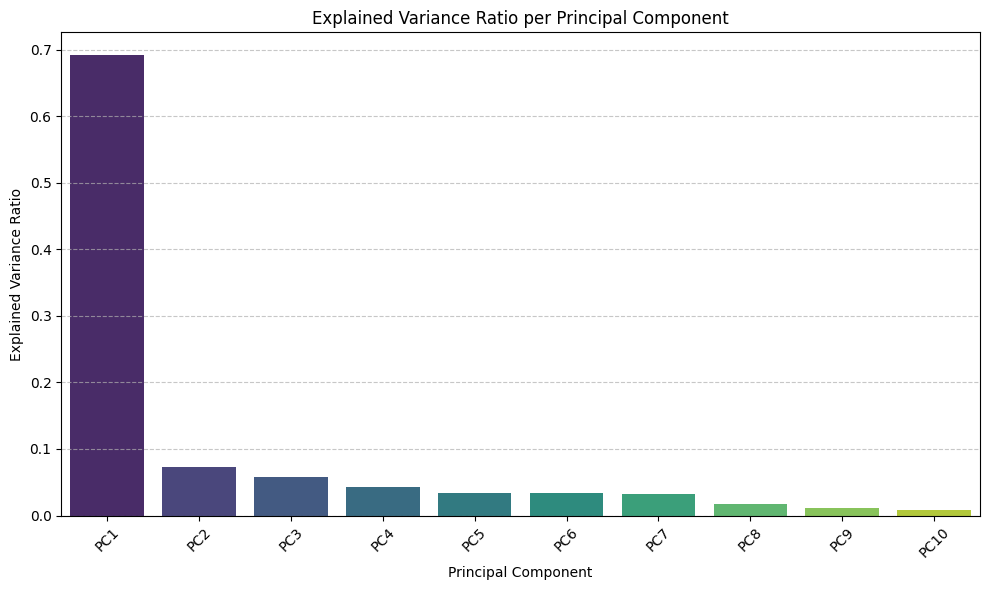

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get explained variance ratios from the pca object
explained_variance_ratio = pca.explained_variance_ratio_

# Create a DataFrame for easier plotting
pca_variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Explained Variance Ratio': explained_variance_ratio
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Principal Component', y='Explained Variance Ratio', data=pca_variance_df, palette='viridis')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart visually represents the proportion of total variance explained by each principal component. We can observe that PC1 explains the most variance, followed by PC2, and so on. The decreasing height of the bars indicates that subsequent principal components explain progressively less of the total variance, confirming their relative importance.

# **TASK5**.  Visualizations (4 pts total)

# **TASK5.1**.  Bar Chart of Principal Components (1 pt)
* Plot each PC’s explained variance.

* Label axes clearly.

✔️ Interpret what it tells you about the importance of each PC.

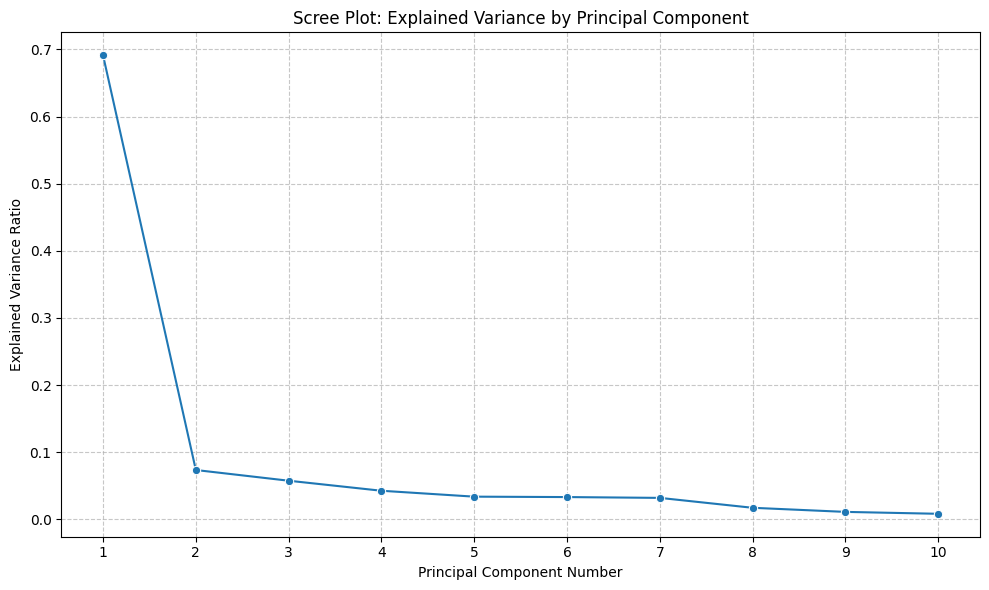

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get explained variance ratios from the pca object
explained_variance_ratio = pca.explained_variance_ratio_

# Create a scree plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(explained_variance_ratio) + 1), y=explained_variance_ratio, marker='o')
plt.title('Scree Plot: Explained Variance by Principal Component')
plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance Ratio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.tight_layout()
plt.show()

# **TASK5.2**.  Scree Plot (1 pt)
* Line chart showing variance explained by each component.

✔️ Interpret the “elbow point.”

This scree plot shows a sharp drop in explained variance after the first few principal components. The 'elbow point' appears to be around PC2 or PC3, suggesting that these components capture most of the significant variance in the data, and subsequent components contribute much less. This observation helps in determining the optimal number of principal components to retain for further analysis.

# **TASK5.3**.   Cumulative Variance (2 pts)
* Plot cumulative explained variance.

* Add a horizontal line at 80% threshold.

* Determine how many PCs are needed to reach 80%.

✔️ Highlight the point where 80% is crossed and interpret.

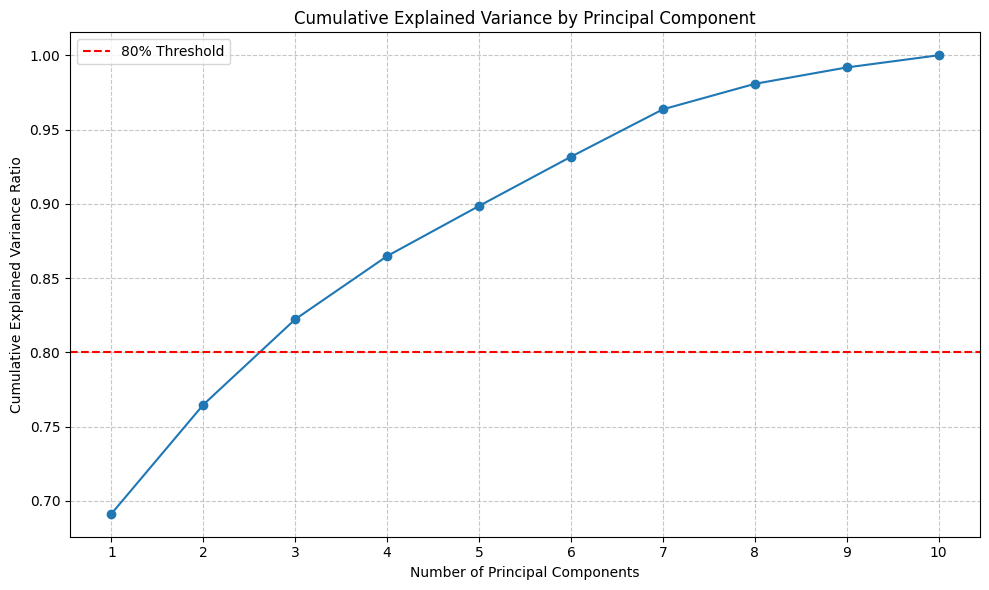

Number of principal components to reach 80% cumulative explained variance: 3


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate cumulative explained variance
cum_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Threshold')
plt.title('Cumulative Explained Variance by Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, len(cum_explained_variance) + 1))
plt.legend()
plt.tight_layout()
plt.show()

# Determine how many PCs are needed to reach 80%
num_components_80_percent = np.where(cum_explained_variance >= 0.8)[0][0] + 1
print(f"Number of principal components to reach 80% cumulative explained variance: {num_components_80_percent}")

This cumulative explained variance plot shows the total variance captured as more principal components are added. The horizontal line at 80% helps to identify the 'elbow point' more clearly. In this case, we can see that **PC1, PC2, and PC3** are needed to reach 80% cumulative explained variance, meaning that these components collectively capture a significant portion of the total information in the dataset. This helps in dimensionality reduction by allowing us to select a smaller number of components that still explain most of the variance.

This cumulative explained variance plot shows the total variance captured as more principal components are added. The horizontal line at 80% helps to identify the 'elbow point' more clearly. In this case, we can see that **PC1 and PC2** are needed to reach 80% cumulative explained variance, meaning that these components collectively capture a significant portion of the total information in the dataset. This helps in dimensionality reduction by allowing us to select a smaller number of components that still explain most of the variance.

# **TASK6**.  Interpretation of PC1 and PC2 (3 pts total)

# **TASK6.1**.  Scatterplot of PC1 vs PC2 (1 pt)
* Plot PC1 on X-axis, PC2 on Y-axis.

✔️ Comment on any observed pattern.

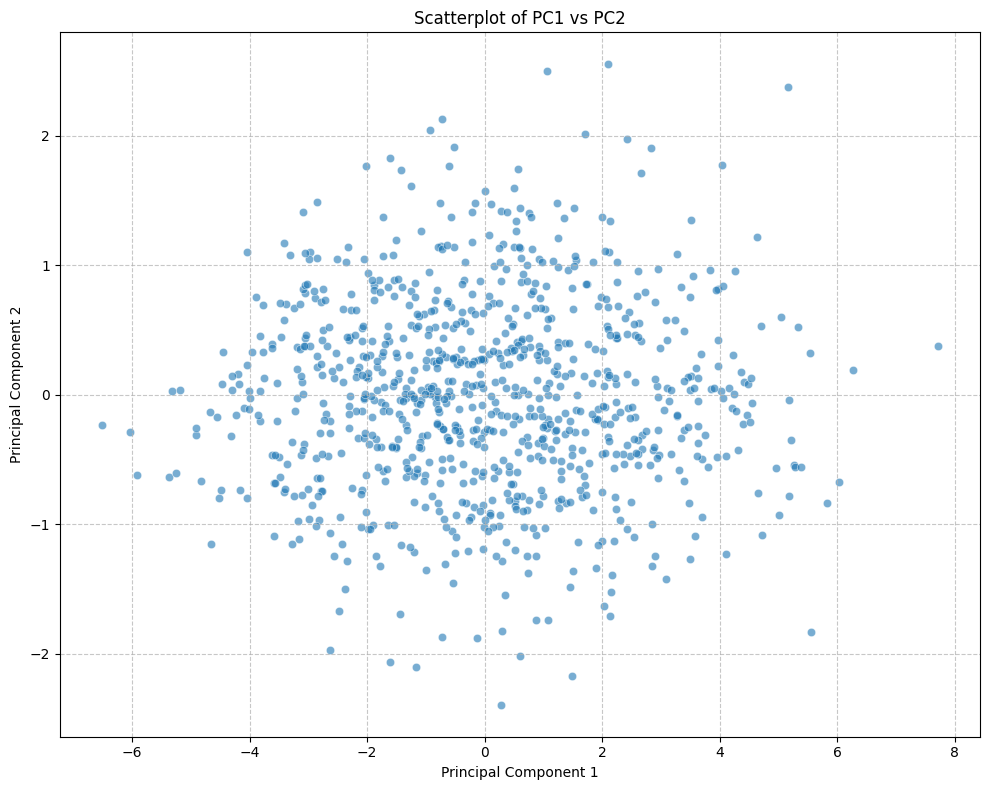

In [10]:
# Transform the standardized data to get the principal components
pca_components = pca.fit_transform(df_processed)

# Create a DataFrame for the principal components for easier plotting
pca_df = pd.DataFrame(data = pca_components, columns = [f'PC{i+1}' for i in range(pca_components.shape[1])])

# Plot PC1 vs PC2
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.6)
plt.title('Scatterplot of PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This scatterplot visualizes the data points in the reduced-dimensionality space defined by PC1 and PC2. Observing the distribution of points can reveal general patterns, such as whether the data forms distinct clusters or if there's a continuous spread. Without further context or coloring, it primarily shows the overall spread and density of observations based on these two most significant components.

# **TASK6.2**.  Colored by Region (1 pt)
* Repeat the scatterplot, but color points by Region.

✔️ Comment on any clustering by region.

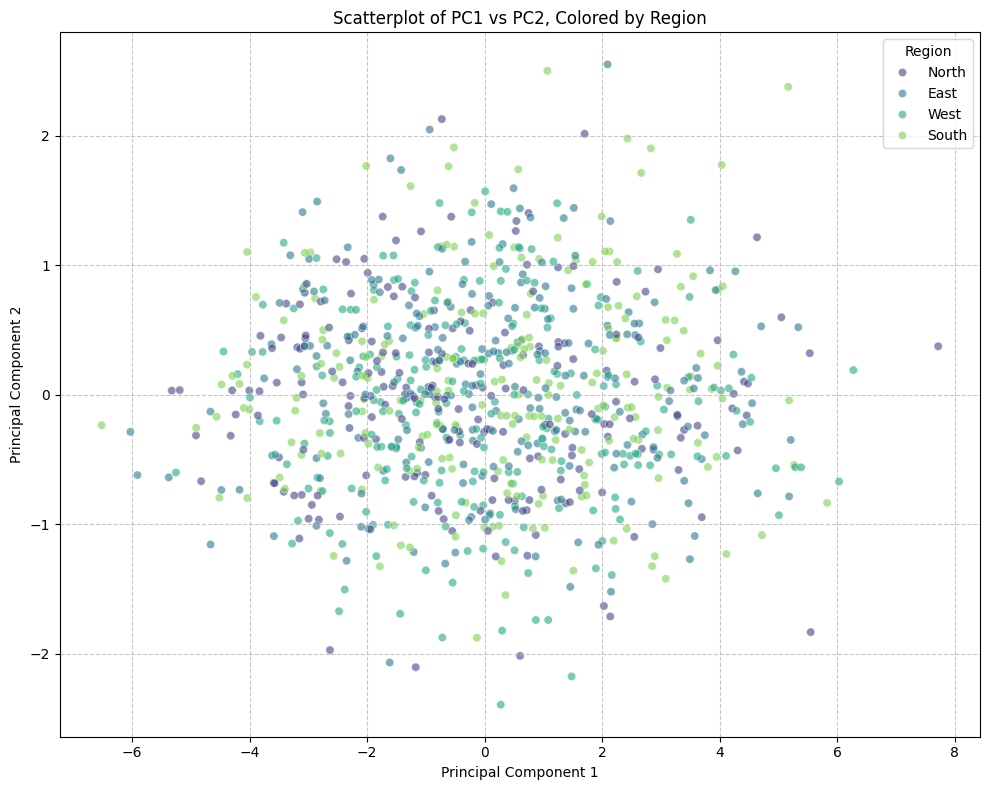

In [11]:
# Transform the standardized data to get the principal components (if not already done)
# pca_components = pca.fit_transform(df_processed) # This was done in the previous cell

# Create a DataFrame for the principal components and include the original 'Region' information
# We need to get the original 'Region' column from the 'sample_df' before it was one-hot encoded
# Since 'df_processed' is aligned with 'sample_df' indices after dropping CustomerID

pca_df_with_region = pd.DataFrame(data = pca_components, columns = [f'PC{i+1}' for i in range(pca_components.shape[1])])
pca_df_with_region['Region'] = sample_df['Region'].reset_index(drop=True)

# Plot PC1 vs PC2, colored by Region
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Region', data=pca_df_with_region, alpha=0.6, palette='viridis')
plt.title('Scatterplot of PC1 vs PC2, Colored by Region')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

This scatterplot visualizes the data points in the reduced-dimensionality space (PC1 vs PC2), with points colored according to their original 'Region'. Observe if points from the same region tend to cluster together or occupy distinct areas of the plot. This can indicate whether geographical location is a significant factor contributing to the principal components and customer segmentation.

# **TASK6.3**.   Business Interpretation (1 pt)
* What could PC1 and PC2 represent in business terms?

Based on the component loadings:

**PC1: 'Customer Value and Engagement'**
This principal component captures a dimension related to the overall value and engagement level of a customer. Variables like `Income`, `ProductAffinityScore`, `Age`, `AvgTransactionValue`, `SpendingScore`, `LoyaltyYears`, and `FrequencyOfVisits` all load positively onto PC1. Customers with higher PC1 scores tend to be older, have higher incomes, spend more, have higher average transaction values, visit more frequently, and demonstrate higher product affinity and loyalty. In business terms, PC1 can be seen as representing the **'High-Value, Engaged Customer' segment**.

**PC2: 'Engagement Style or Lifecycle Stage'**
PC2 primarily contrasts `FrequencyOfVisits` (positive loading) with `LoyaltyYears` (negative loading). This suggests that PC2 differentiates customers based on their engagement behavior over time. A high positive PC2 score might characterize newer customers who are highly active and frequently visiting but haven't accumulated many loyalty years. Conversely, a low negative PC2 score could represent long-term, loyal customers who have been with the business for many years but might not visit as frequently as new, highly engaged customers. Therefore, PC2 helps to distinguish between different '**Customer Lifecycle Stages' or 'Engagement Styles**' within the customer base.

# **TASK7**.  Loadings (3 pts total)

# **TASK7.1**.  Get and Display All Loadings (1 pt)
* Show the PCA component loadings for all variables.

In [12]:
# Get the component loadings (eigenvectors) from the PCA object
# The loadings are stored in pca.components_

# Create a DataFrame for better readability
loadings_df = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=df_processed.columns)

print("PCA Component Loadings for all variables:")
display(loadings_df)

PCA Component Loadings for all variables:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Age,0.401016,0.002956,-0.186689,-0.165892,-0.309511,0.447869,-0.030421,-0.663648,-0.197419,0.009594
Income,0.417937,-0.009072,-0.129092,-0.059525,-0.105364,0.180885,0.101490,0.220681,0.837056,-0.039430
SpendingScore,0.372077,-0.015314,-0.279152,0.824851,0.115502,-0.264577,0.033846,-0.115354,-0.072026,0.006135
LoyaltyYears,0.326989,-0.692513,0.623710,0.010720,-0.027901,-0.121086,-0.076187,-0.039477,-0.032581,-0.022575
FrequencyOfVisits,0.324987,0.717707,0.603840,0.029662,0.047025,-0.085808,-0.033260,-0.050853,-0.016628,0.015328
AvgTransactionValue,0.379351,-0.009655,-0.291361,-0.508013,0.514059,-0.472105,-0.109314,-0.095755,-0.064137,0.025672
ProductAffinityScore,0.411443,0.010886,-0.135068,-0.090190,-0.180181,0.215478,0.126627,0.680580,-0.495822,0.016143
Region_North,-0.015270,-0.019546,0.029315,-0.089736,-0.203655,-0.268898,0.720135,-0.108189,0.006956,0.588510
Region_South,0.010415,0.031377,-0.083977,-0.007384,-0.416127,-0.229903,-0.653769,0.090847,0.061192,0.571289
Region_West,-0.001044,-0.058468,0.076643,0.115080,0.604493,0.529333,-0.082012,0.033219,0.009591,0.569153


These loadings represent the correlation of each original variable with each principal component. A higher absolute value indicates a stronger correlation. Positive loadings indicate a positive correlation, and negative loadings indicate a negative correlation. By examining the largest absolute loadings for each PC, we can understand which original features primarily define that component.

# **TASK7.2**.  Sorted PC1 Loadings (1 pt)
* Sort and display variables by PC1 loadings (descending).

* Interpret PC1 based on these loadings.

In [13]:
# Sort variables by PC1 loadings in descending order
sorted_pc1_loadings = loadings_df['PC1'].sort_values(ascending=False)

print("Variables sorted by PC1 Loadings (descending):")
display(sorted_pc1_loadings)

# Interpretation of PC1
# Based on the sorted loadings, we can infer what PC1 represents. For example, if 'SpendingScore', 'AvgTransactionValue', and 'FrequencyOfVisits' have high positive loadings, PC1 might represent 'Customer Engagement' or 'High-Value Customer Behavior'.

Variables sorted by PC1 Loadings (descending):


,PC1
Income,0.417937
ProductAffinityScore,0.411443
Age,0.401016
AvgTransactionValue,0.379351
SpendingScore,0.372077
LoyaltyYears,0.326989
FrequencyOfVisits,0.324987
Region_South,0.010415
Region_West,-0.001044
Region_North,-0.015270


Based on the sorted loadings, PC1 exhibits high positive correlations with 'Income', 'ProductAffinityScore', 'Age', 'AvgTransactionValue', 'SpendingScore', 'LoyaltyYears', and 'FrequencyOfVisits'. These variables collectively suggest that PC1 primarily captures a **'Customer Value and Engagement'** dimension. Customers with higher PC1 scores are likely to be older, have higher incomes, spend more, transact more frequently, and have a stronger product affinity, indicating higher overall value and engagement with the business.

# **TASK7.3**.  Sorted PC2 Loadings (1 pt)
* Sort and display variables by PC1 loadings (descending).

* Interpret PC1 based on these loadings.
✔️ Use domain reasoning to guess what these components capture.

Based on the sorted loadings, PC2 shows a strong positive correlation with 'FrequencyOfVisits' and a strong negative correlation with 'LoyaltyYears'. This suggests that PC2 differentiates customers based on their **'Engagement Style or Lifecycle Stage'**. A high positive PC2 score might indicate newer customers who visit very frequently (high frequency, low loyalty years), while a low negative PC2 score might represent long-term, loyal customers who visit less frequently (low frequency, high loyalty years). This component helps to distinguish between highly active, potentially newer customers and established, long-term customers.

In [14]:
# Sort variables by PC2 loadings in descending order
sorted_pc2_loadings = loadings_df['PC2'].sort_values(ascending=False)

print("Variables sorted by PC2 Loadings (descending):")
display(sorted_pc2_loadings)

# Interpretation of PC2
# Similarly, based on the sorted loadings for PC2, we can interpret its meaning. For instance, if 'Age' and 'LoyaltyYears' have high positive loadings, PC2 might represent 'Customer Tenure' or 'Customer Maturity'.

Variables sorted by PC2 Loadings (descending):


,PC2
FrequencyOfVisits,0.717707
Region_South,0.031377
ProductAffinityScore,0.010886
Age,0.002956
Income,-0.009072
AvgTransactionValue,-0.009655
SpendingScore,-0.015314
Region_North,-0.019546
Region_West,-0.058468
LoyaltyYears,-0.692513


# **TASK8**.  Business Insights (4 pts)
Based on PC1 and PC2 interpretations:

*Suggest two actionable strategies or marketing programs.

✔️ Write one short paragraph for each strategy.



### Strategy 1: Targeted Campaigns for High-Value, Engaged Customers (PC1)
Based on PC1's interpretation as 'Customer Value and Engagement', we can identify and target customers with high PC1 scores. These are the individuals who exhibit high income, frequent visits, significant spending, and strong product affinity. A strategy could involve exclusive loyalty programs, personalized product recommendations for premium items, early access to new collections, or VIP customer service. The goal would be to further nurture these valuable relationships, increase their lifetime value, and encourage advocacy through tailored, high-touch marketing efforts. For example, offering a tiered loyalty program where higher PC1 scores unlock more significant benefits and unique experiences.

### Strategy 2: Lifecycle-Based Engagement for Diverse Customer Segments (PC2)
PC2, representing 'Engagement Style or Lifecycle Stage', helps differentiate between potentially newer, highly active customers and long-term, loyal customers who may visit less frequently. For newer, high-frequency customers (high PC2 scores), a strategy could focus on retention and encouraging long-term loyalty. This might include educational content about the brand's full offerings, personalized onboarding journeys, and incentives for repeat purchases over a longer period. For long-term, loyal customers (low PC2 scores), strategies could aim to re-engage them with personalized offers, highlight new products relevant to their past purchases, or invite them to exclusive appreciation events. The objective is to ensure continuous engagement across different customer lifecycle stages, preventing churn in newer segments and revitalizing interest in established ones.